In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [3]:
# plt format

plt.rcParams['font.sans-serif'] = 'Roboto'   # Specific font name
plt.rcParams['font.size'] = 12              # Default text size in points
plt.rcParams['font.style'] = 'normal'       # Options: normal, italic, oblique
plt.rcParams['font.weight'] = 'normal'      # Options: normal, bold, etc.
plt.rcParams["lines.linewidth"] = 3.0  # Set global default line width

In [4]:
# importing csv

df = pd.read_csv("../datasets/sales_data_cln.csv").copy()

In [5]:
# checking columns
df.columns

Index(['user_id', 'order_id', 'purchase_ts', 'ship_ts', 'refund_ts',
       'product_name', 'product_id', 'usd_price', 'purchase_platform',
       'marketing_channel', 'account_creation_method', 'country_code',
       'purchase_y', 'purchase_ym', 'purchase_ymd', 'purchase_ymw',
       'purchase_q', 'ship_y', 'ship_ym', 'ship_ymd', 'ship_ymw', 'ship_q'],
      dtype='object')

In [6]:
# filter the completed orders
co = df[df["refund_ts"].isna()]

# generate revenue data
rev_data_ym = co.groupby("purchase_ym").agg(total_revenue=("usd_price", "sum"), total_orders = ("order_id", "count")).reset_index()

# set back to datetime for plt purposes
rev_data_ym["purchase_ym"] = pd.to_datetime(rev_data_ym["purchase_ym"], format="%Y-%m")

In [7]:
rev_data_ym["ym_aov"] = (rev_data_ym["total_revenue"] / rev_data_ym["total_orders"]).round(2)

low_rev = rev_data_ym.nsmallest(3, columns='total_revenue')
high_rev = rev_data_ym.nlargest(3, columns='total_revenue')


In [8]:
high_rev

,purchase_ym,total_revenue,total_orders,ym_aov
23,2020-12-01,407720.69,1217,335.02
20,2020-09-01,319785.04,1076,297.20
15,2020-04-01,295996.15,1075,275.35


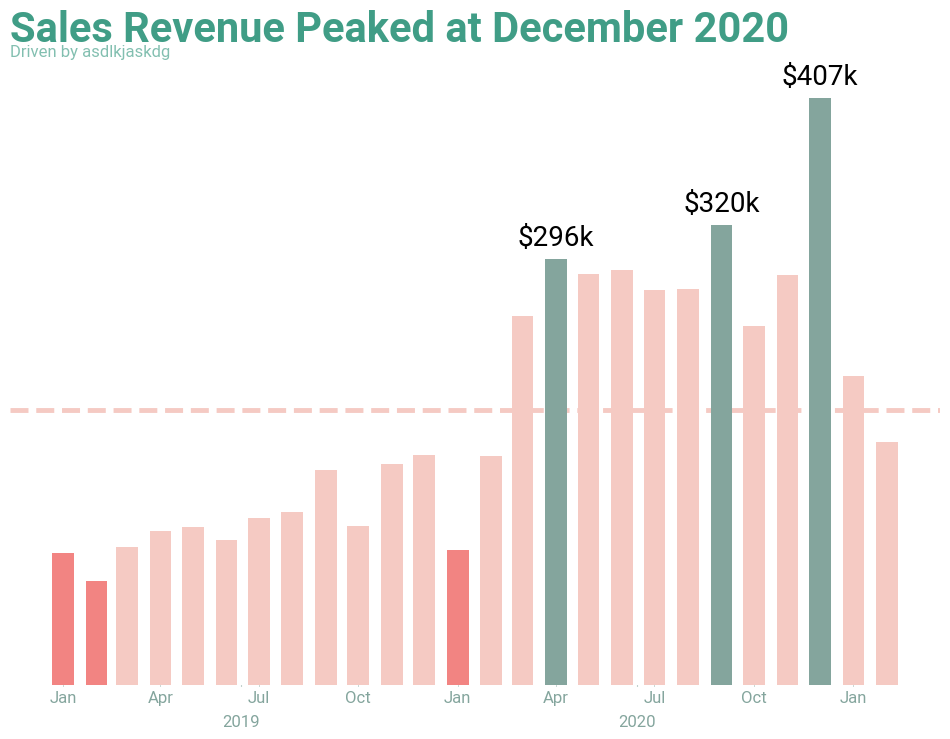

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

# line avg
ax.axhline(
    y=rev_data_ym["total_revenue"].mean(), color="#f5cac3",
    linestyle='--', linewidth=3.5, zorder=0)
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_revenue"],
    width = 20, color = "#f5cac3")
ax.bar(low_rev["purchase_ym"], low_rev["total_revenue"],
    width = 20, color = "#f28482")
ax.bar(high_rev["purchase_ym"], high_rev["total_revenue"],
    width = 20, color = "#84a59d")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
# ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])


#####
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# years (major ticks), placed mid-year so they don't collide with Jan/Jul
ax.xaxis.set_major_locator(mdates.YearLocator(month=6, day=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.tick_params(axis="x", which="major", pad=20, length=1, colors= "#84a59d") # params for years
ax.tick_params(axis="x", which="minor", pad=3, length=1, colors= "#84a59d") # params for months


# ------------------------------------------------------
# ----------- title, texts, and annotations ---------
# ------------------------------------------------------
# title
ax.set_title(
    "Sales Revenue Peaked at December 2020",
    fontsize=30,
    fontweight="bold",
    loc="left",
    color = "#409d86",
    pad=20
)

# Subtitle
ax.text(
    0,
    1.02,
    "Driven by asdlkjaskdg",
    transform=ax.transAxes,
    fontsize=12,
    color = "#409d86",
    alpha=0.65
)


# annotation
top_idx = high_rev.loc[high_rev["total_revenue"].idxmax()]
top2_idx = high_rev.loc[high_rev["total_revenue"].nlargest(2).idxmin()]
top3_idx = high_rev.loc[high_rev["total_revenue"].nlargest(3).idxmin()]


ax.annotate(
    "$407k",
    xy=(top_idx["purchase_ym"], top_idx["total_revenue"]),  # tip of the arrow = top of that bar
    xytext=(0, 10),                                        # text 40 points above the arrow tip
    textcoords="offset points",
    ha="center",
    fontsize = 20,
    # arrowprops=dict(arrowstyle="->", lw=2, color="black"),
    # annotation_clip=False,                                 # draw even if outside the axes
    zorder=10
)

ax.annotate(
    "$320k",
    xy=(top2_idx["purchase_ym"], top2_idx["total_revenue"]),  # tip of the arrow = top of that bar
    xytext=(0, 10),                                        # text 40 points above the arrow tip
    textcoords="offset points",
    ha="center",
    fontsize = 20,
    # arrowprops=dict(arrowstyle="->", lw=2, color="black"),
    # annotation_clip=False,                                 # draw even if outside the axes
    zorder=10
)

ax.annotate(
    "$296k",
    xy=(top3_idx["purchase_ym"], top3_idx["total_revenue"]),  # tip of the arrow = top of that bar
    xytext=(0, 10),                                        # text 40 points above the arrow tip
    textcoords="offset points",
    ha="center",
    fontsize = 20,
    # arrowprops=dict(arrowstyle="->", lw=2, color="black"),
    # annotation_clip=False,                                 # draw even if outside the axes
    zorder=10
)

plt.savefig("../figures/executive_summary/executive_summary.png", transparent=True, dpi=300)

plt.show()

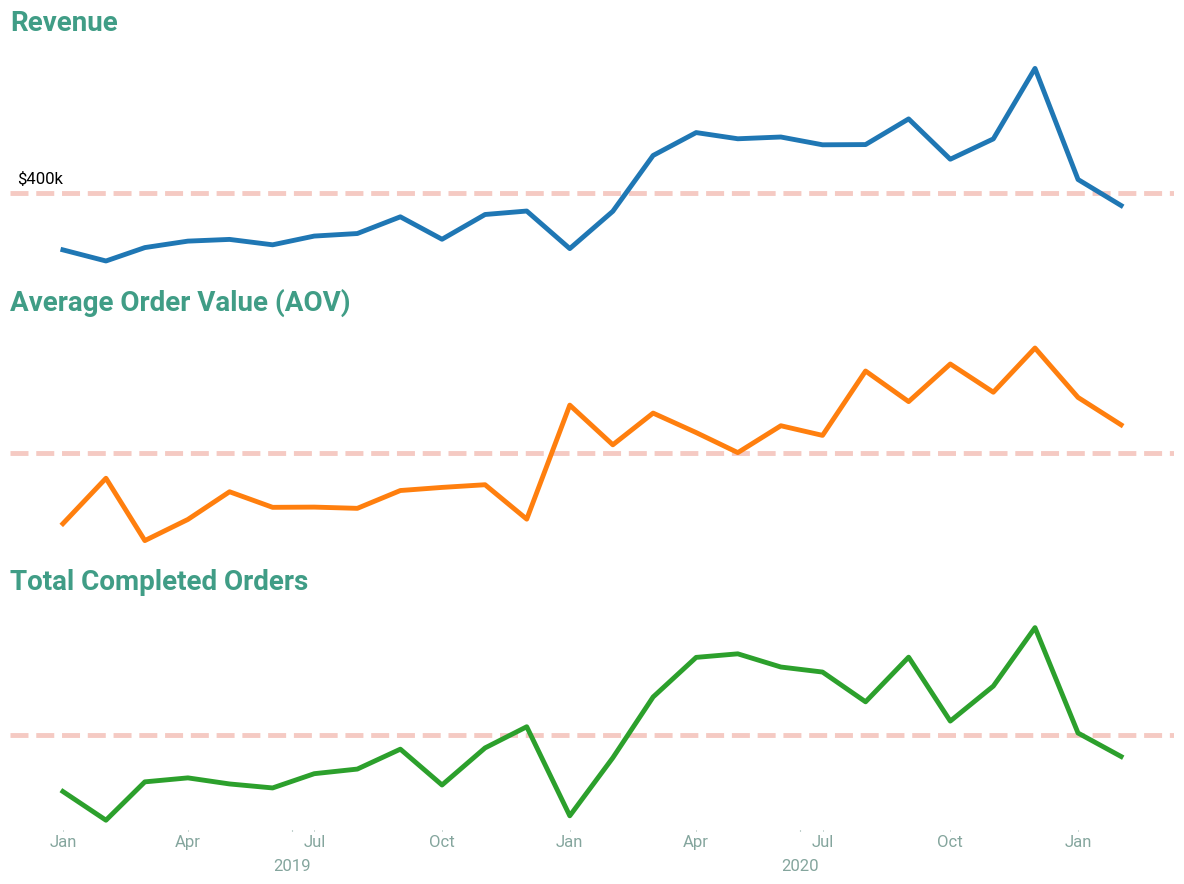

In [10]:
# Create 3 stacked subplots sharing the x-axis
fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(12, 9))

# Plot data on each axis
# ax[0].axhline(y=rev_data_ym["total_revenue"].mean(), color='red', linestyle='--', linewidth=1)
ax[0].plot(rev_data_ym["purchase_ym"], rev_data_ym["total_revenue"],
    color='tab:blue', linewidth=3.5)

ax[0].axhline(y=rev_data_ym["total_revenue"].mean(), color="#f5cac3",
    linestyle='--', linewidth=3.5, zorder=0)

ax[0].set_title(
    "Revenue",
    fontsize=20,
    fontweight="bold",
    loc="left",
    color = "#409d86",
    pad=20
)

ax[0].annotate("$400k", xy=(0, rev_data_ym["total_revenue"].mean()),
    xycoords=("axes fraction", "data"),  # x: 0-1 across the axes, y: data value
    xytext=(5, 4),                       # 5 pts right, 4 pts above the line
    textcoords="offset points", ha="left", va="bottom",
    fontsize=12,)

ax[0].set_ylabel('total_revenue')
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_visible(False)
ax[0].spines["bottom"].set_visible(False)
ax[0].axes.get_xaxis().set_visible(False)
ax[0].axes.get_yaxis().set_visible(False)



# ax[1].axhline(y=rev_data_ym["ym_aov"].mean(), color='red', linestyle='--', linewidth=1)
ax[1].plot(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov"], color='tab:orange', linewidth=3.5)
ax[1].axhline(y=rev_data_ym["ym_aov"].mean(), color="#f5cac3",
    linestyle='--', linewidth=3.5, zorder=0)


ax[1].set_ylabel('aov')
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["left"].set_visible(False)
ax[1].spines["bottom"].set_visible(False)
ax[1].axes.get_xaxis().set_visible(False)
ax[1].axes.get_yaxis().set_visible(False)

ax[1].set_title("Average Order Value (AOV)",
    fontsize=20, fontweight="bold",
    loc="left", color = "#409d86", pad=20)


# ax[2].axhline(y=rev_data_ym["total_orders"].mean(), color='red', linestyle='--', linewidth=1)
ax[2].plot(rev_data_ym["purchase_ym"], rev_data_ym["total_orders"], color='tab:green', linewidth=3.5)
ax[2].axhline(y=rev_data_ym["total_orders"].mean(), color="#f5cac3",
    linestyle='--', linewidth=3.5, zorder=0)

ax[2].set_ylabel('total_orders')
ax[2].spines["top"].set_visible(False)
ax[2].spines["right"].set_visible(False)
ax[2].spines["left"].set_visible(False)
ax[2].spines["bottom"].set_visible(False)
# ax[2].axes.get_xaxis().set_visible(False)
ax[2].axes.get_yaxis().set_visible(False)

ax[2].set_title(
    "Total Completed Orders",
    fontsize=20,
    fontweight="bold",
    loc="left",
    color = "#409d86",
    pad=20
)

# Set the x-label on the bottom plot only
# ax[2].set_xlabel('X Axis')


#####
ax[2].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax[2].xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# years (major ticks), placed mid-year so they don't collide with Jan/Jul
ax[2].xaxis.set_major_locator(mdates.YearLocator(month=6, day=15))
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

#params for years
ax[2].tick_params(axis="x", which="major", pad=20, length=1, 
    colors= "#84a59d")
# params for months
ax[2].tick_params(axis="x", which="minor", pad=3, length=1,
    colors= "#84a59d") 



fig.subplots_adjust(hspace=0)
# Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig("../figures/sales/sales.png", transparent=True, dpi=300)
plt.show()

In [11]:
rev_data_ym["total_rev_growth_pct"] = (100.0 * (rev_data_ym["total_revenue"] - rev_data_ym["total_revenue"].shift(1))/rev_data_ym["total_revenue"]).round(1)
rev_data_ym["total_orders_growth_pct"] = (100.0 * (rev_data_ym["total_orders"] - rev_data_ym["total_orders"].shift(1))/rev_data_ym["total_orders"]).round(1)
rev_data_ym["ym_aov_growth_pct"] = (100.0 * (rev_data_ym["ym_aov"] - rev_data_ym["ym_aov"].shift(1))/rev_data_ym["ym_aov"]).round(1)
rev_data_ym

,purchase_ym,total_revenue,total_orders,ym_aov,total_rev_growth_pct,total_orders_growth_pct,ym_aov_growth_pct
0,2019-01-01,91802.39,435,211.04,NaN,NaN,NaN
1,2019-02-01,72440.62,298,243.09,-26.7,-46.0,13.2
2,2019-03-01,95762.11,481,199.09,24.4,38.0,-22.1
3,2019-04-01,107012.02,500,214.02,10.5,3.8,7.0
4,2019-05-01,110005.20,471,233.56,2.7,-6.2,8.4
5,2019-06-01,100603.50,452,222.57,-9.3,-4.2,-4.9
6,2019-07-01,115821.61,520,222.73,13.1,13.1,0.1
7,2019-08-01,120240.82,542,221.85,3.7,4.1,-0.4
8,2019-09-01,149331.91,637,234.43,19.5,14.9,5.4
9,2019-10-01,110267.37,466,236.63,-35.4,-36.7,0.9


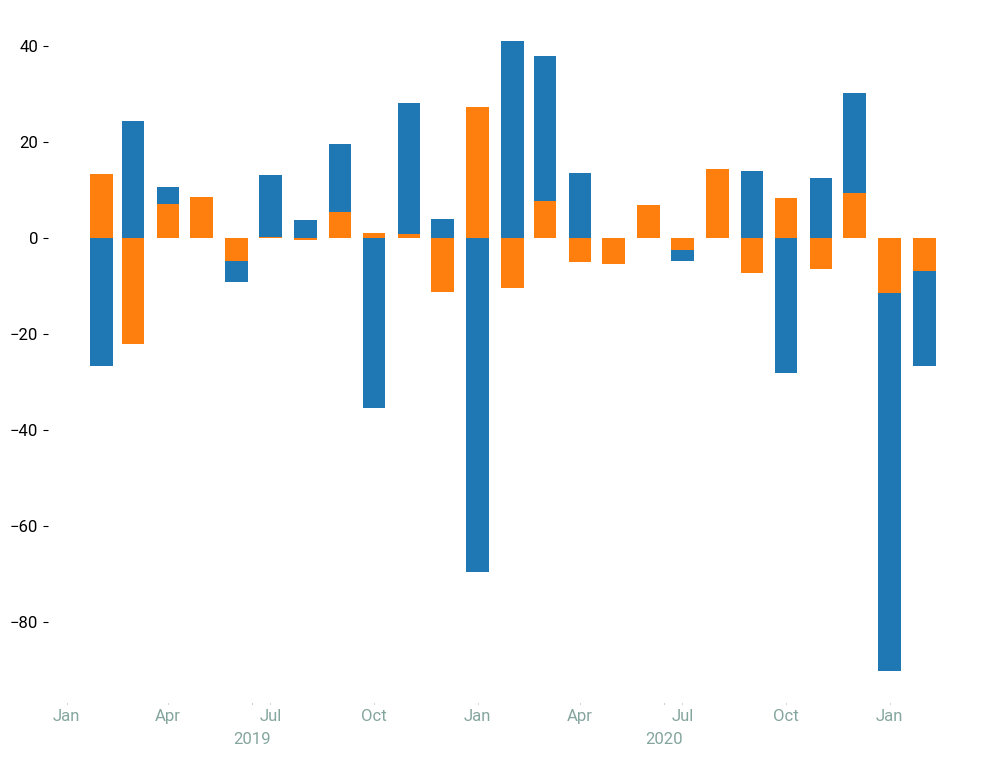

In [21]:
fig, ax = plt.subplots(figsize=(12, 9))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

# ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_orders_growth_pct"], width=20)
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_rev_growth_pct"], width=20)
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov_growth_pct"], width=20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
# ax.axes.get_xaxis().set_visible(False)
# ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])

ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# years (major ticks), placed mid-year so they don't collide with Jan/Jul
ax.xaxis.set_major_locator(mdates.YearLocator(month=6, day=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.tick_params(axis="x", which="major", pad=20, length=1, colors= "#84a59d") # params for years
ax.tick_params(axis="x", which="minor", pad=3, length=1, colors= "#84a59d") # params for months



plt.savefig("../figures/sales/sales_vs_aov.png", transparent=True, dpi=300)

plt.show()